# AI Usage in Regulatory Documents

Analysis of LLM-assisted writing prevalence across federal regulatory documents using Distributional GPT Detection (Liang et al. 2025).

**Alpha estimate**: The estimated fraction of text that is AI-generated (0 = fully human, 1 = fully AI).

In [30]:
# still running, pull again in the morning...

In [79]:
# Re-run this cell to pull latest results from sk3
import subprocess

version = '/v2/'
version = '/'

cmds = [
    f"rsync -avz sk3:/lfs/skampere3/0/alexspan/regulations-demo/data/bulk_downloads/scripts/data{version}ai_usage_results.csv "
    "../data/bulk_downloads/scripts/data/ai_usage_results.csv",
    "rsync -avz --include='*.parquet' --include='*.csv' --include='*.json' --exclude='*' "
    f"sk3:/lfs/skampere3/0/alexspan/regulations-demo/data/bulk_downloads/scripts/data{version}ai_usage_distributions/ "
    "../data/bulk_downloads/scripts/data/ai_usage_distributions/",
]
for cmd in cmds:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(result.stdout.strip())
    if result.returncode != 0:
        print(f"ERROR: {result.stderr.strip()}")

receiving incremental file list
ai_usage_results.csv

sent 2,173 bytes  received 39,549 bytes  27,814.67 bytes/sec
total size is 237,180  speedup is 5.68
receiving incremental file list
./
distribution_metadata.json
distribution_notice.parquet
distribution_proposed_rule.parquet
distribution_public_submission.parquet
distribution_rule.parquet

sent 14,789 bytes  received 1,657,528 bytes  1,114,878.00 bytes/sec
total size is 2,228,142  speedup is 1.33


In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

RESULTS_PATH = '../data/bulk_downloads/scripts/data/ai_usage_results.csv'
df = pd.read_csv(RESULTS_PATH)
df['year'] = df['year'].astype(int)
df['quarter_dt'] = pd.PeriodIndex(df['quarter'], freq='Q').to_timestamp()
print(f"Loaded {len(df)} rows: {df['doc_type'].nunique()} doc types, {df['agency_id'].nunique()} agencies, {df['year'].min()}-{df['year'].max()}")
df.head()

Loaded 2642 rows: 4 doc types, 29 agencies, 2016-2026


,doc_type,agency_id,quarter,year,alpha_estimate,ci_lower,ci_upper,n_documents,n_sentences,distribution_file,quarter_dt
0,notice,AMS,2017Q1,2017,0.000007,0.000007,0.000007,15,4423,distribution_notice.parquet,2017-01-01
1,notice,AMS,2017Q2,2017,0.000007,0.000007,0.000007,9,3327,distribution_notice.parquet,2017-04-01
2,notice,AMS,2017Q3,2017,0.000007,0.000007,0.000007,5,1131,distribution_notice.parquet,2017-07-01
3,notice,AMS,2017Q4,2017,0.000007,0.000007,0.000007,8,2677,distribution_notice.parquet,2017-10-01
4,notice,AMS,2018Q1,2018,0.000007,0.000007,0.000007,1,163,distribution_notice.parquet,2018-01-01


In [81]:
df['doc_type'].value_counts()

doc_type
notice               783
public_submission    707
rule                 621
proposed_rule        531
Name: count, dtype: int64

## 1. Overall AI Usage Over Time (by doc type)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/3595968422.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


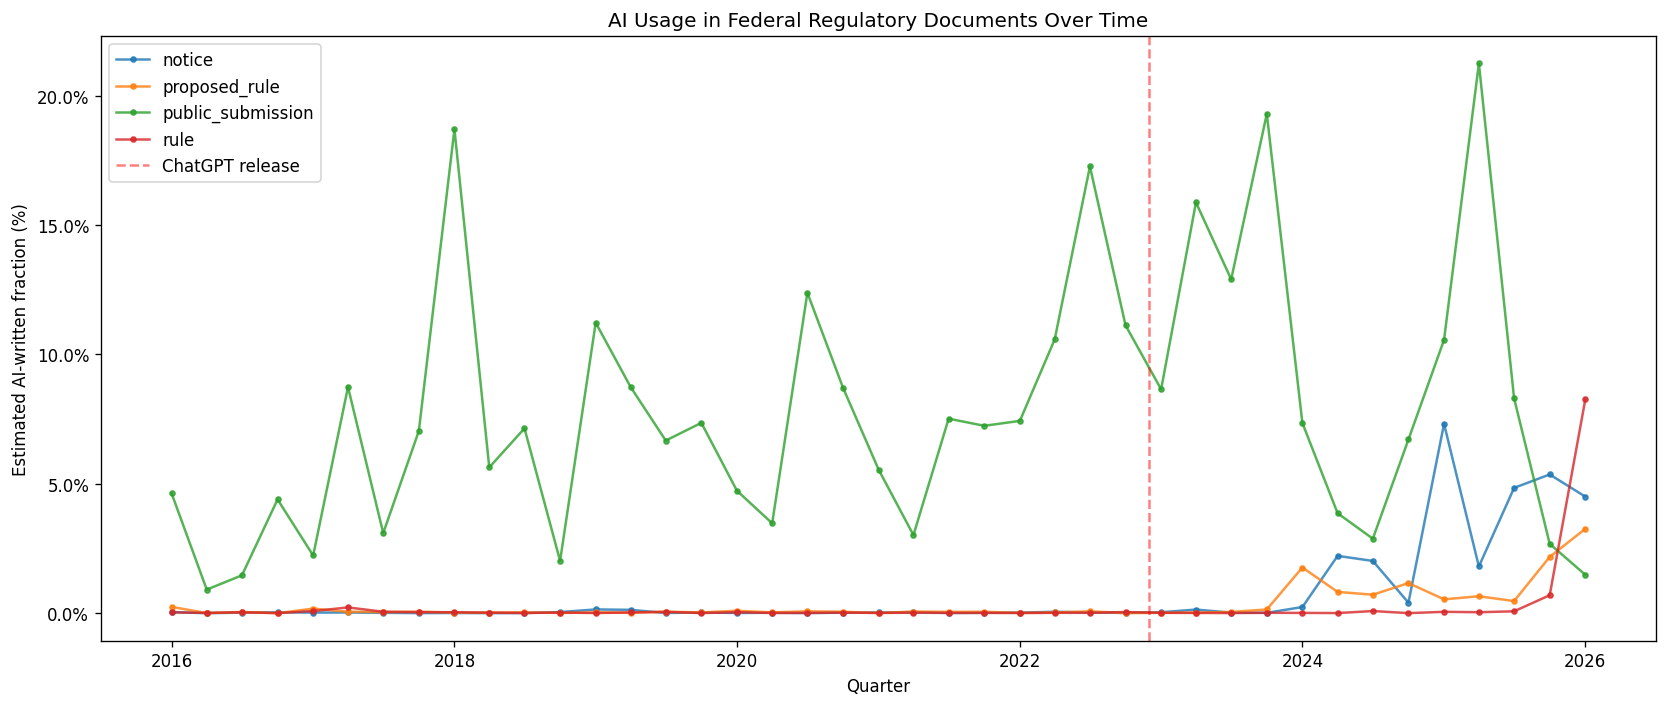

In [82]:
# Aggregate across agencies: weighted mean by n_sentences
time_agg = (
    df.groupby(['doc_type', 'quarter_dt'])
    .apply(lambda g: pd.Series({
        'alpha_weighted': np.average(g['alpha_estimate'], weights=g['n_sentences']),
        'n_documents': g['n_documents'].sum(),
        'n_sentences': g['n_sentences'].sum(),
    }))
    .reset_index()
)

fig, ax = plt.subplots()
for doc_type, grp in (
    time_agg
        #.loc[lambda df: df['doc_type'] != 'public_submission']
    .groupby('doc_type')
):
    grp = grp.sort_values('quarter_dt')
    ax.plot(grp['quarter_dt'], grp['alpha_weighted'] * 100, marker='.', label=doc_type, alpha=0.8)

ax.axvline(pd.Timestamp('2022-11-30'), color='red', linestyle='--', alpha=0.5, label='ChatGPT release')
ax.set_xlabel('Quarter')
ax.set_ylabel('Estimated AI-written fraction (%)')
ax.set_title('AI Usage in Federal Regulatory Documents Over Time')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
plt.tight_layout()
plt.show()

## 2. Pre vs Post ChatGPT Comparison

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/3734148439.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


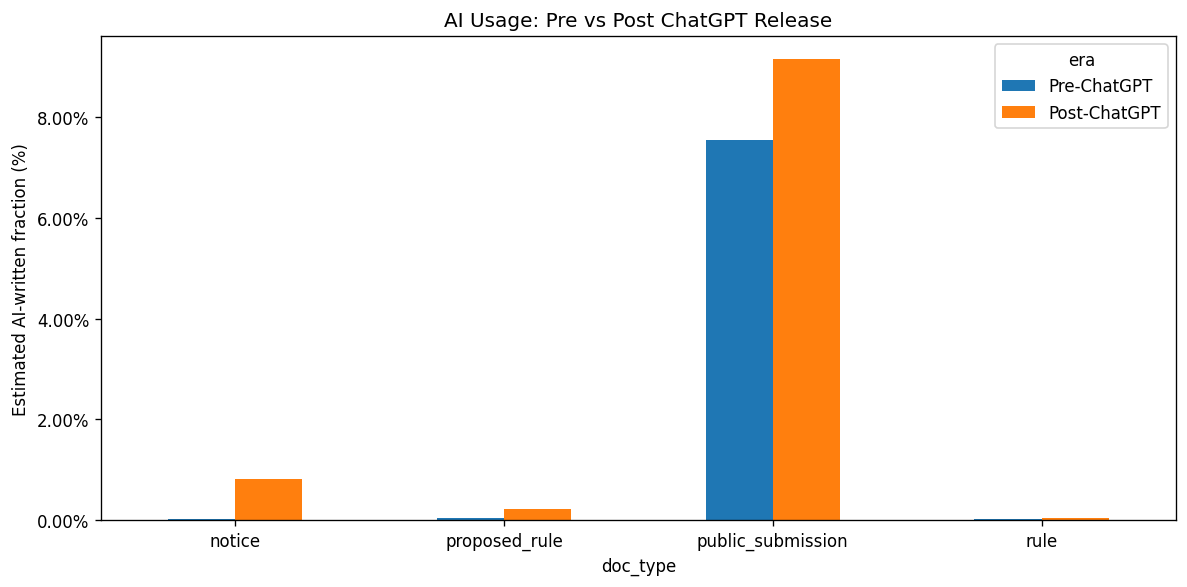

         doc_type          era  alpha_weighted  alpha_mean  alpha_median  n_documents  n_strata
           notice Post-ChatGPT        0.008153    0.013945      0.000007      11107.0     157.0
           notice  Pre-ChatGPT        0.000289    0.000413      0.000007      43520.0     626.0
    proposed_rule Post-ChatGPT        0.002276    0.005068      0.000007       1498.0      97.0
    proposed_rule  Pre-ChatGPT        0.000453    0.001061      0.000007       9268.0     434.0
public_submission Post-ChatGPT        0.091542    0.085153      0.030641    2037191.0     227.0
public_submission  Pre-ChatGPT        0.075445    0.057686      0.015182    4160533.0     480.0
             rule Post-ChatGPT        0.000352    0.001296      0.000007       1649.0      96.0
             rule  Pre-ChatGPT        0.000292    0.000493      0.000007      10974.0     525.0


In [83]:
df['era'] = np.where(df['quarter_dt'] < '2022-12-01', 'Pre-ChatGPT', 'Post-ChatGPT')

era_agg = (
    df.groupby(['doc_type', 'era'])
    .apply(lambda g: pd.Series({
        'alpha_weighted': np.average(g['alpha_estimate'], weights=g['n_sentences']),
        'alpha_mean': g['alpha_estimate'].mean(),
        'alpha_median': g['alpha_estimate'].median(),
        'n_documents': g['n_documents'].sum(),
        'n_strata': len(g),
    }))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
era_pivot = era_agg.pivot(index='doc_type', columns='era', values='alpha_weighted')
era_pivot = era_pivot[['Pre-ChatGPT', 'Post-ChatGPT']]  # order columns
(era_pivot * 100).plot.bar(ax=ax, rot=0)
ax.set_ylabel('Estimated AI-written fraction (%)')
ax.set_title('AI Usage: Pre vs Post ChatGPT Release')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
plt.tight_layout()
plt.show()

print(era_agg.to_string(index=False))

## 3. Top Agencies by AI Usage (Post-ChatGPT)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/750258125.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


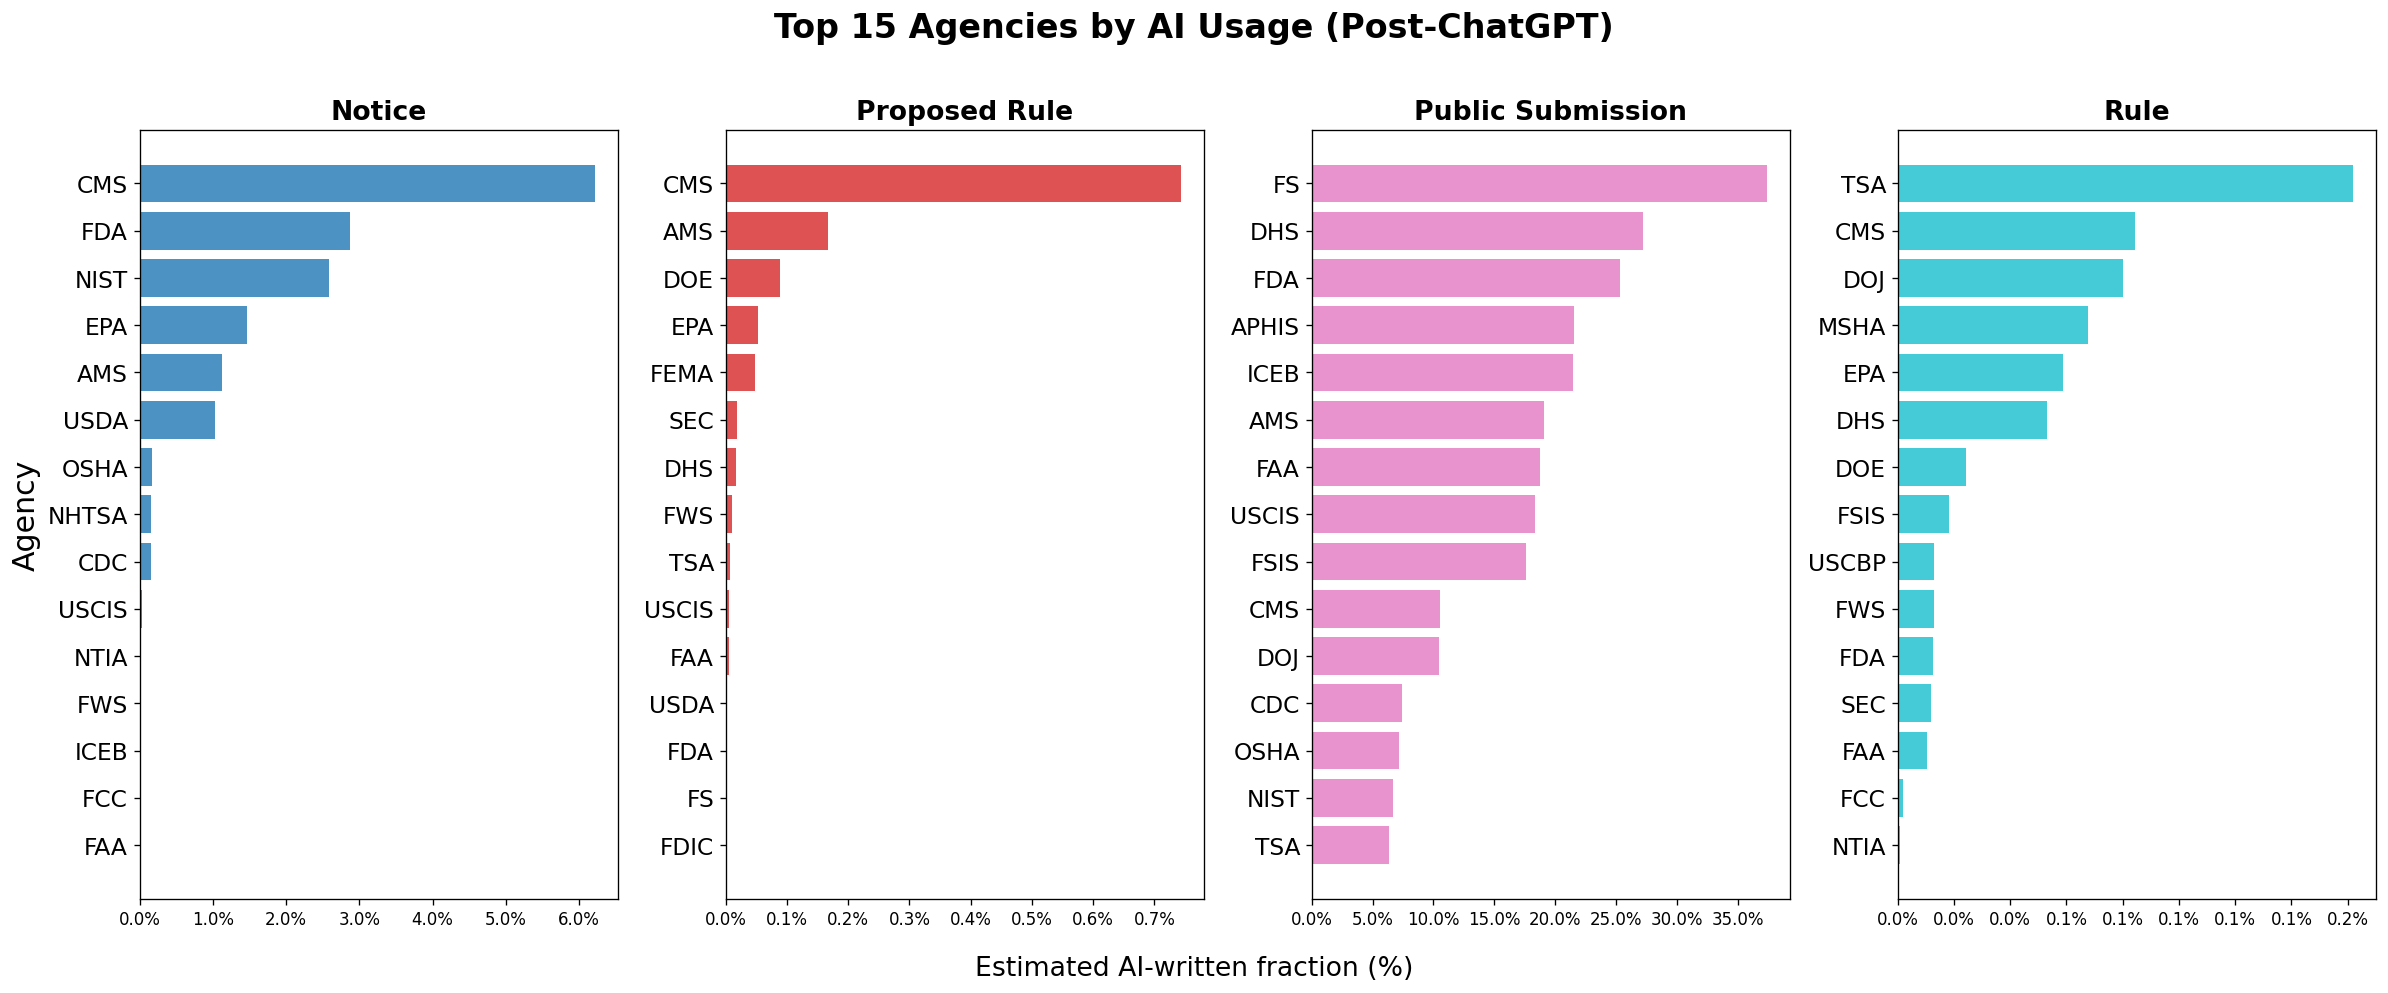

In [84]:
post_chatgpt = df[df['era'] == 'Post-ChatGPT']

agency_agg = (
    post_chatgpt.groupby(['doc_type', 'agency_id'])
    .apply(lambda g: pd.Series({
        'alpha_weighted': np.average(g['alpha_estimate'], weights=g['n_sentences']),
        'n_documents': g['n_documents'].sum(),
        'n_sentences': g['n_sentences'].sum(),
    }))
    .reset_index()
)

doc_types = sorted(agency_agg['doc_type'].unique())
n_types = len(doc_types)
fig, axes = plt.subplots(1, n_types, figsize=(5 * n_types, 8), sharey=False, sharex=False)
if n_types == 1:
    axes = [axes]

for ax, doc_type in zip(axes, doc_types):
    subset = agency_agg[agency_agg['doc_type'] == doc_type].copy()
    subset = subset.sort_values('alpha_weighted', ascending=True).tail(15)

    colors = plt.cm.tab10(doc_types.index(doc_type) / max(n_types - 1, 1))
    ax.barh(subset['agency_id'], subset['alpha_weighted'] * 100, color=colors, alpha=0.8)
    ax.set_title(doc_type.replace('_', ' ').title(), fontsize=16, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    if ax == axes[0]:
        ax.set_ylabel('Agency', fontsize=18)
    ax.tick_params(axis='y', labelsize=14)

fig.suptitle('Top 15 Agencies by AI Usage (Post-ChatGPT)', fontsize=20, fontweight='bold', y=1.02)
fig.supxlabel('Estimated AI-written fraction (%)', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Year-over-Year Change by Agency (Post-ChatGPT)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/863613779.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


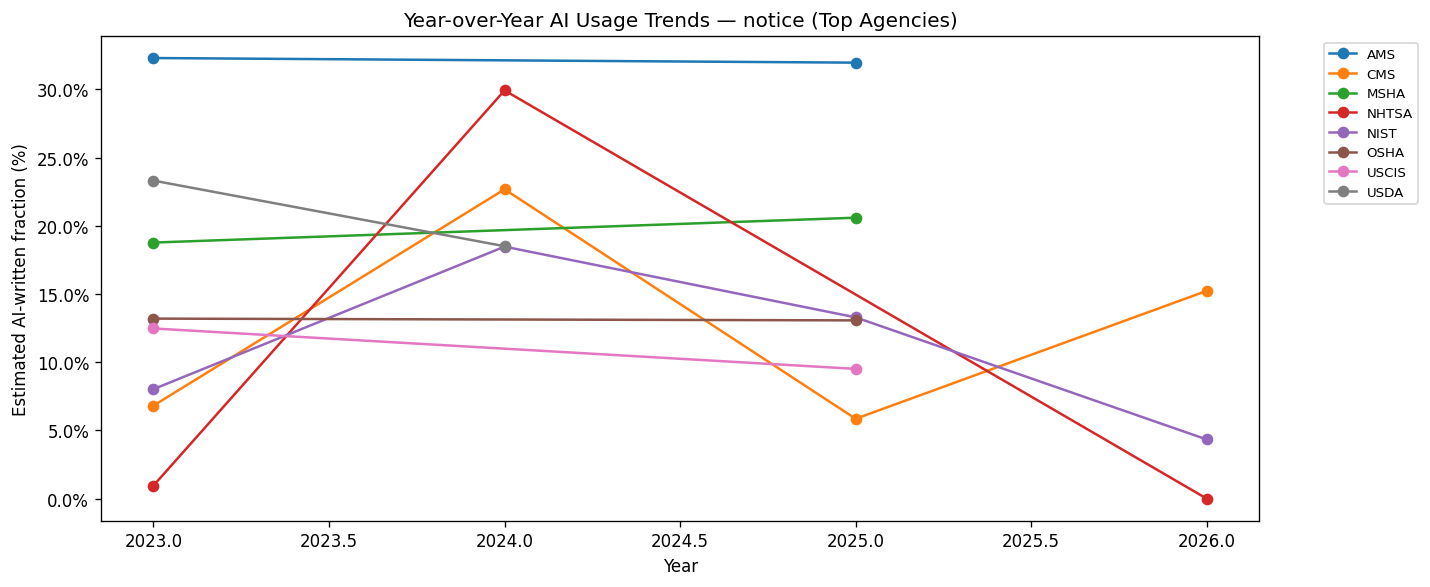

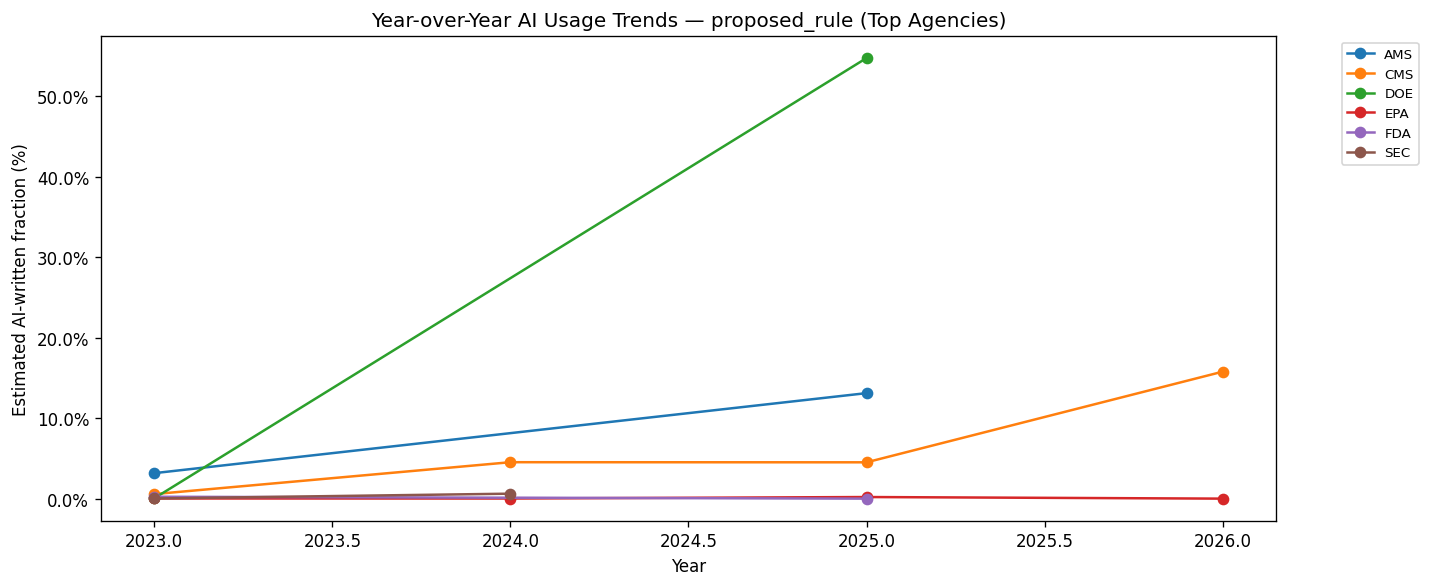

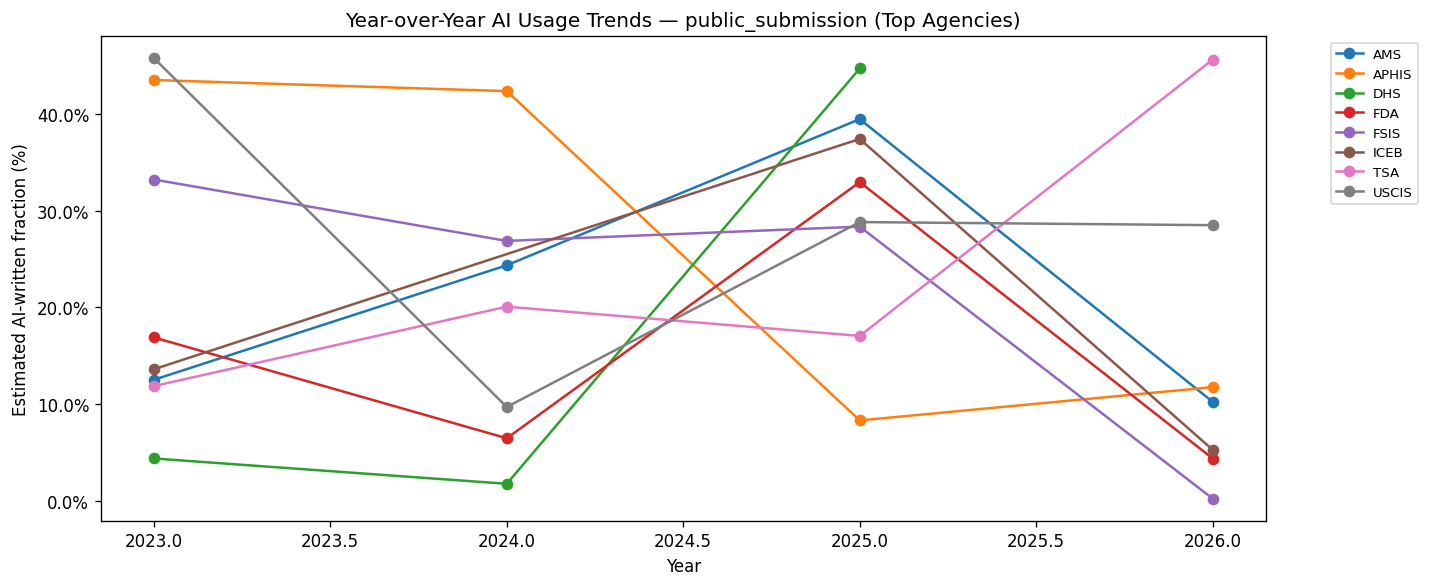

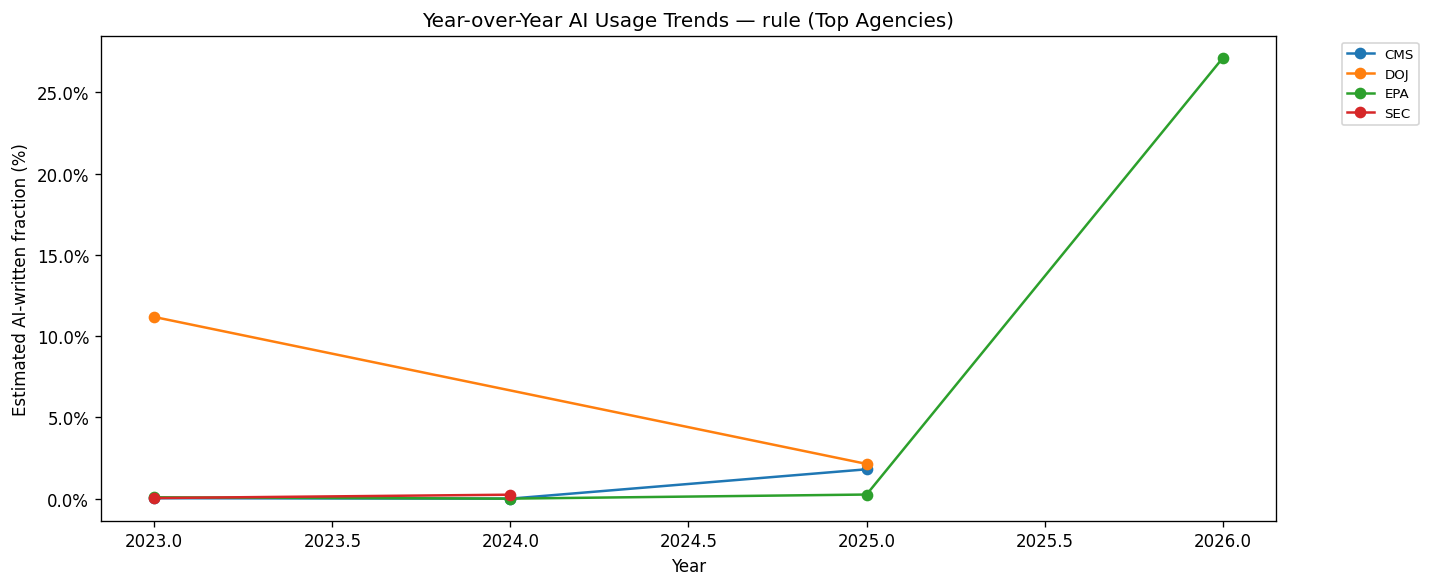

In [77]:
# Focus on agencies with sufficient data
post_yearly = (
    post_chatgpt.groupby(['doc_type', 'agency_id', 'year'])
    .apply(lambda g: pd.Series({
        'alpha_weighted': np.average(g['alpha_estimate'], weights=g['n_sentences']),
        'n_documents': g['n_documents'].sum(),
    }))
    .reset_index()
)

# Only agencies with data in 2+ post-ChatGPT years
multi_year = post_yearly.groupby(['doc_type', 'agency_id']).filter(lambda g: g['year'].nunique() >= 2)

for doc_type in multi_year['doc_type'].unique():
    subset = multi_year[multi_year['doc_type'] == doc_type]
    # Pick top 8 agencies by max alpha
    top_agencies = (
        subset.groupby('agency_id')['alpha_weighted'].max()
        .nlargest(8).index
    )
    subset = subset[subset['agency_id'].isin(top_agencies)]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    for agency, grp in subset.groupby('agency_id'):
        grp = grp.sort_values('year')
        ax.plot(grp['year'], grp['alpha_weighted'] * 100, marker='o', label=agency)
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Estimated AI-written fraction (%)')
    ax.set_title(f'Year-over-Year AI Usage Trends — {doc_type} (Top Agencies)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    plt.tight_layout()
    plt.show()

## 5. Confidence Intervals — Recent Quarters

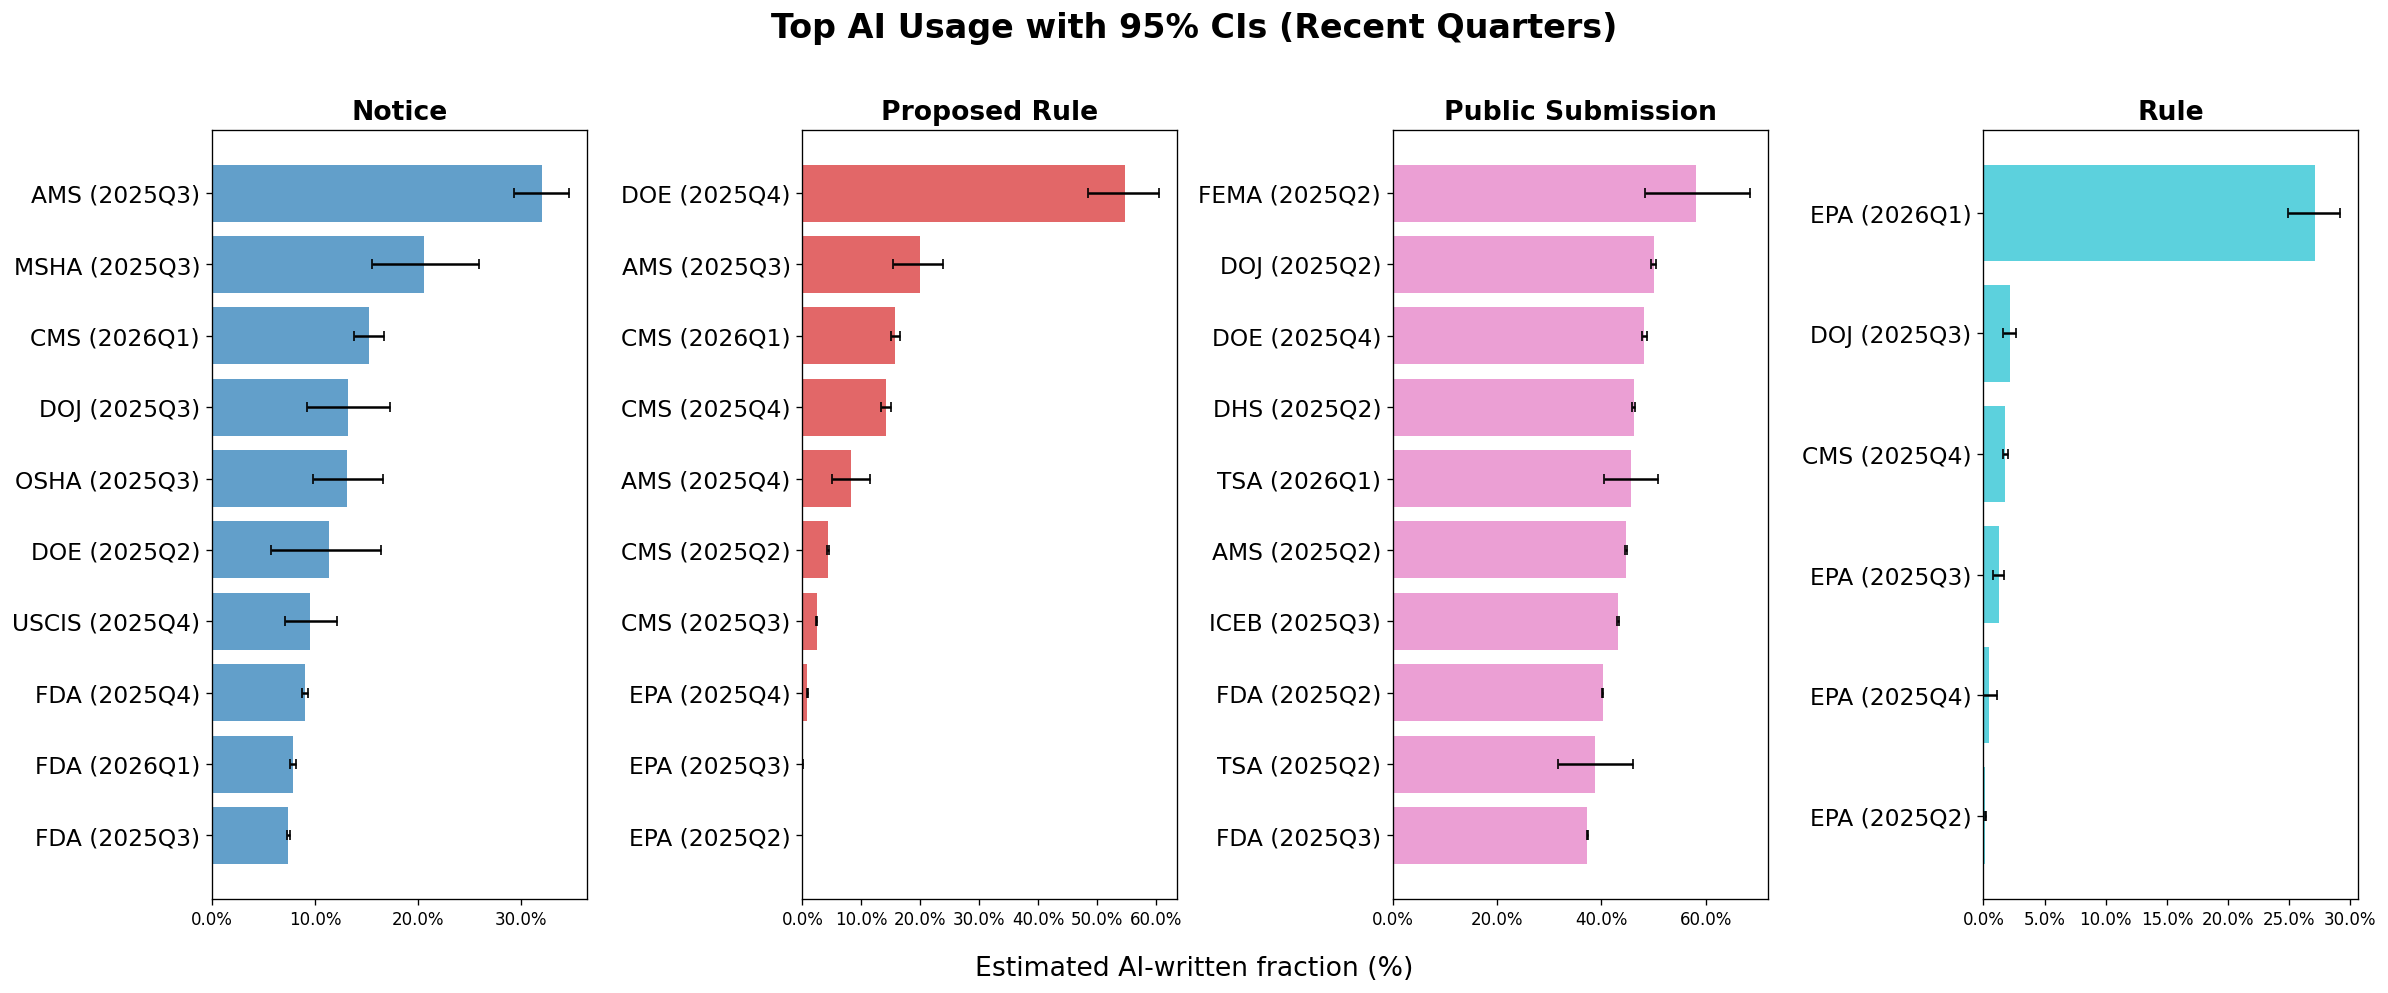

In [78]:
# Show the most recent 4 quarters with CIs for top agencies
recent_quarters = sorted(df['quarter'].unique())[-4:]
recent = df[df['quarter'].isin(recent_quarters)].copy()

doc_types = sorted(recent['doc_type'].unique())
n_types = len(doc_types)
fig, axes = plt.subplots(1, n_types, figsize=(5 * n_types, 8), sharey=False, sharex=False)
if n_types == 1:
    axes = [axes]

for ax, doc_type in zip(axes, doc_types):
    subset = recent[recent['doc_type'] == doc_type].copy()
    top = subset.nlargest(10, 'alpha_estimate')

    labels = top['agency_id'] + ' (' + top['quarter'] + ')'
    y_pos = range(len(top))
    colors = plt.cm.tab10(doc_types.index(doc_type) / max(n_types - 1, 1))
    ax.barh(y_pos, top['alpha_estimate'] * 100, xerr=[
        (top['alpha_estimate'] - top['ci_lower']).values * 100,
        (top['ci_upper'] - top['alpha_estimate']).values * 100
    ], capsize=3, alpha=0.7, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(doc_type.replace('_', ' ').title(), fontsize=16, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='y', labelsize=14)

fig.suptitle('Top AI Usage with 95% CIs (Recent Quarters)', fontsize=20, fontweight='bold', y=1.02)
fig.supxlabel('Estimated AI-written fraction (%)', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [46]:
summary = (
    df.groupby(['doc_type', 'era'])
    .agg(
        n_strata=('alpha_estimate', 'count'),
        total_docs=('n_documents', 'sum'),
        total_sentences=('n_sentences', 'sum'),
        alpha_mean=('alpha_estimate', 'mean'),
        alpha_median=('alpha_estimate', 'median'),
        alpha_max=('alpha_estimate', 'max'),
        alpha_p90=('alpha_estimate', lambda x: x.quantile(0.9)),
    )
    .reset_index()
)

# Format percentages
for col in ['alpha_mean', 'alpha_median', 'alpha_max', 'alpha_p90']:
    summary[col] = (summary[col] * 100).round(3).astype(str) + '%'

summary

,doc_type,era,n_strata,total_docs,total_sentences,alpha_mean,alpha_median,alpha_max,alpha_p90
0,notice,Post-ChatGPT,157,11107,8353150,1.395%,0.001%,40.748%,3.374%
1,notice,Pre-ChatGPT,626,43520,22078467,0.041%,0.001%,4.792%,0.025%
2,proposed_rule,Post-ChatGPT,97,1498,4311037,0.507%,0.001%,14.244%,1.008%
3,proposed_rule,Pre-ChatGPT,434,9268,15440016,0.106%,0.001%,27.768%,0.034%
4,public_submission,Post-ChatGPT,227,2037191,77759432,8.515%,3.064%,75.492%,23.557%
5,public_submission,Pre-ChatGPT,480,4160533,129790679,5.769%,1.518%,54.979%,17.034%
6,rule,Post-ChatGPT,96,1649,3403382,0.13%,0.001%,8.258%,0.059%
7,rule,Pre-ChatGPT,525,10974,17338872,0.049%,0.001%,4.832%,0.044%


## 7. Heatmap: Agency x Year

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/1671630497.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['alpha_estimate'], weights=g['n_sentences']))


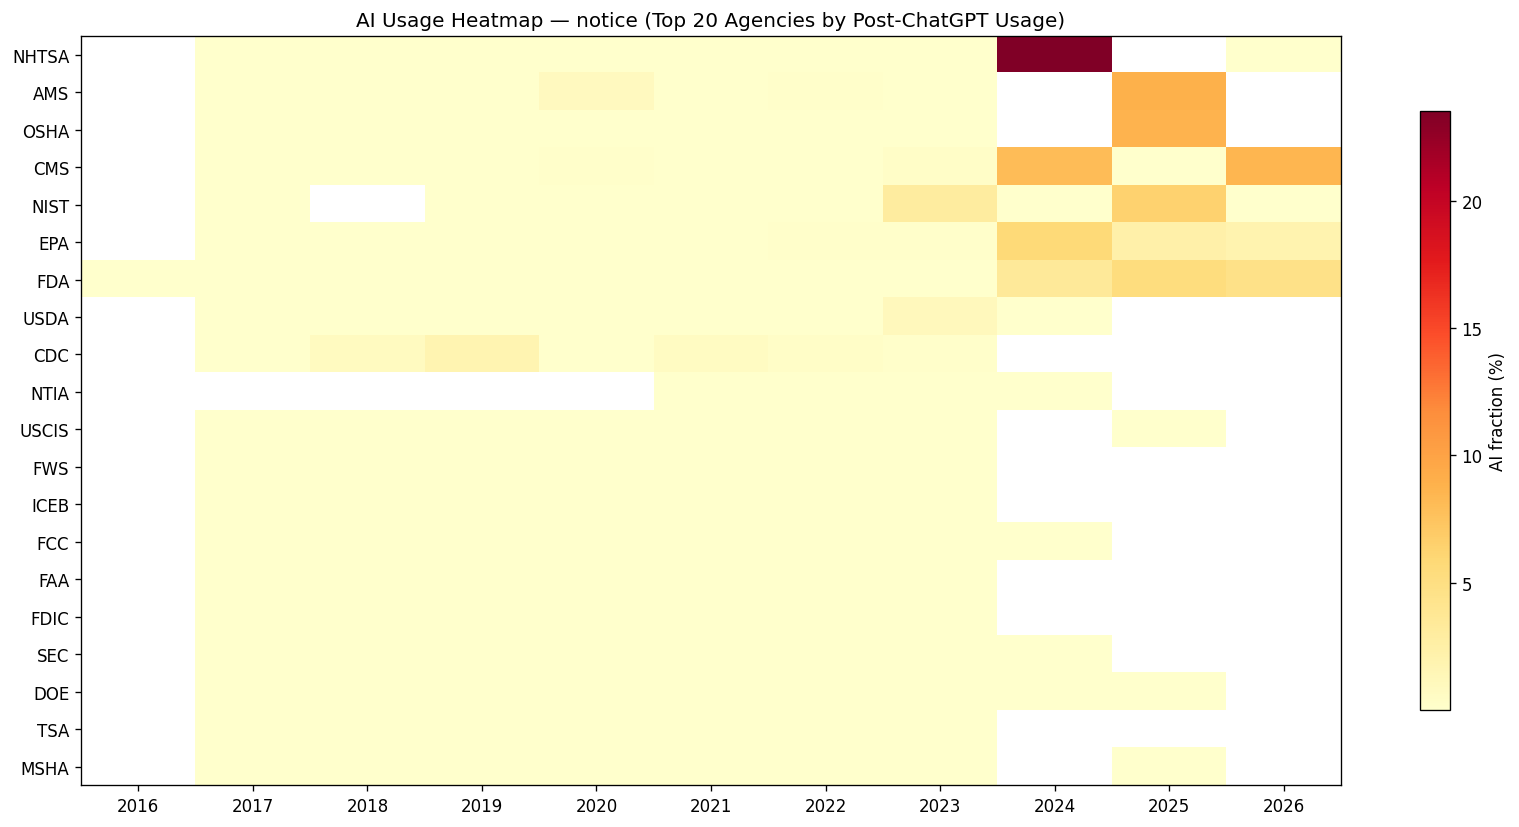

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/1671630497.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['alpha_estimate'], weights=g['n_sentences']))


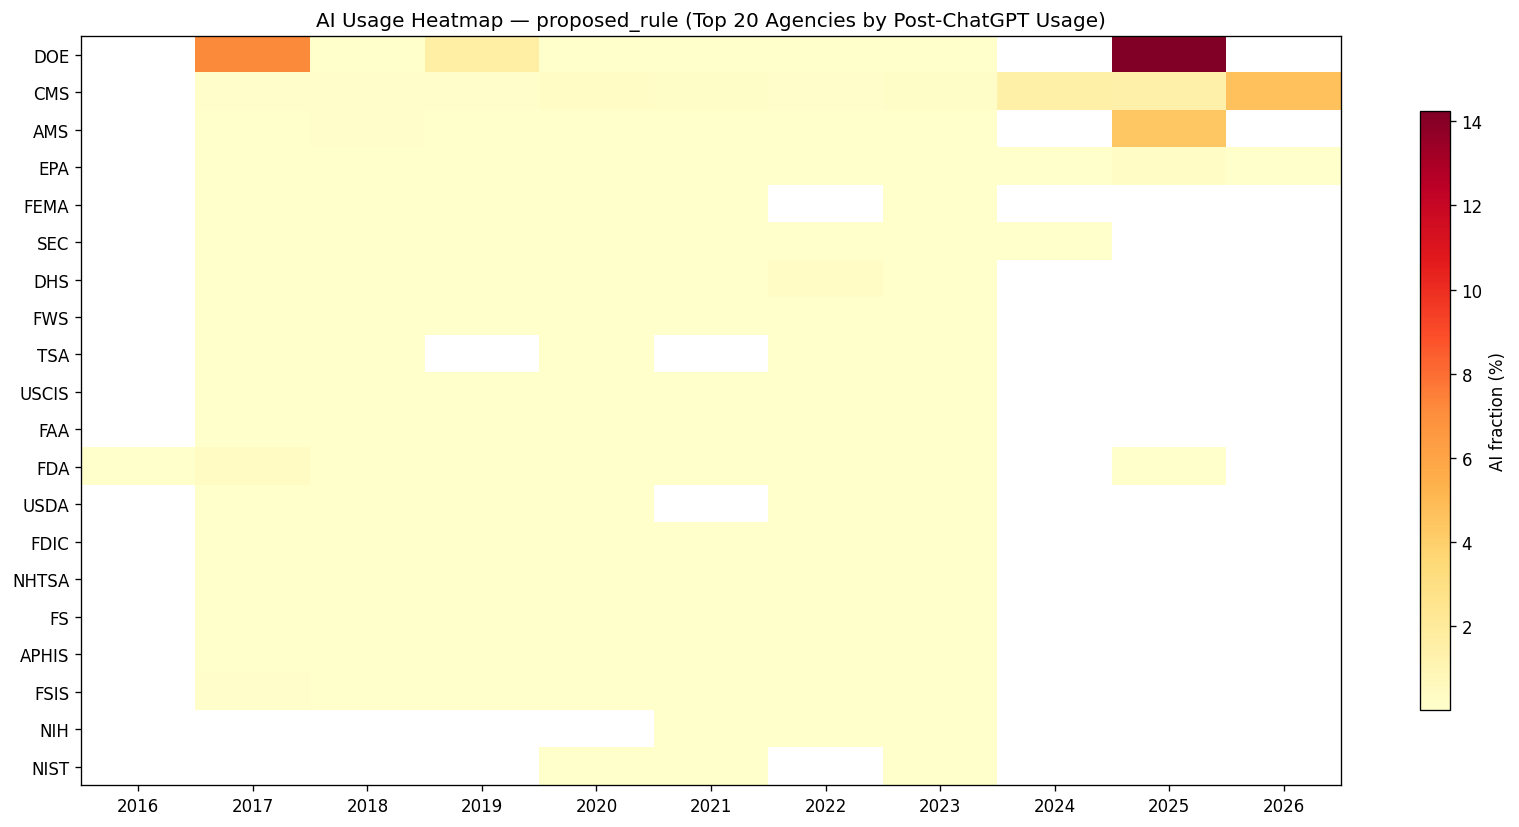

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/1671630497.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['alpha_estimate'], weights=g['n_sentences']))


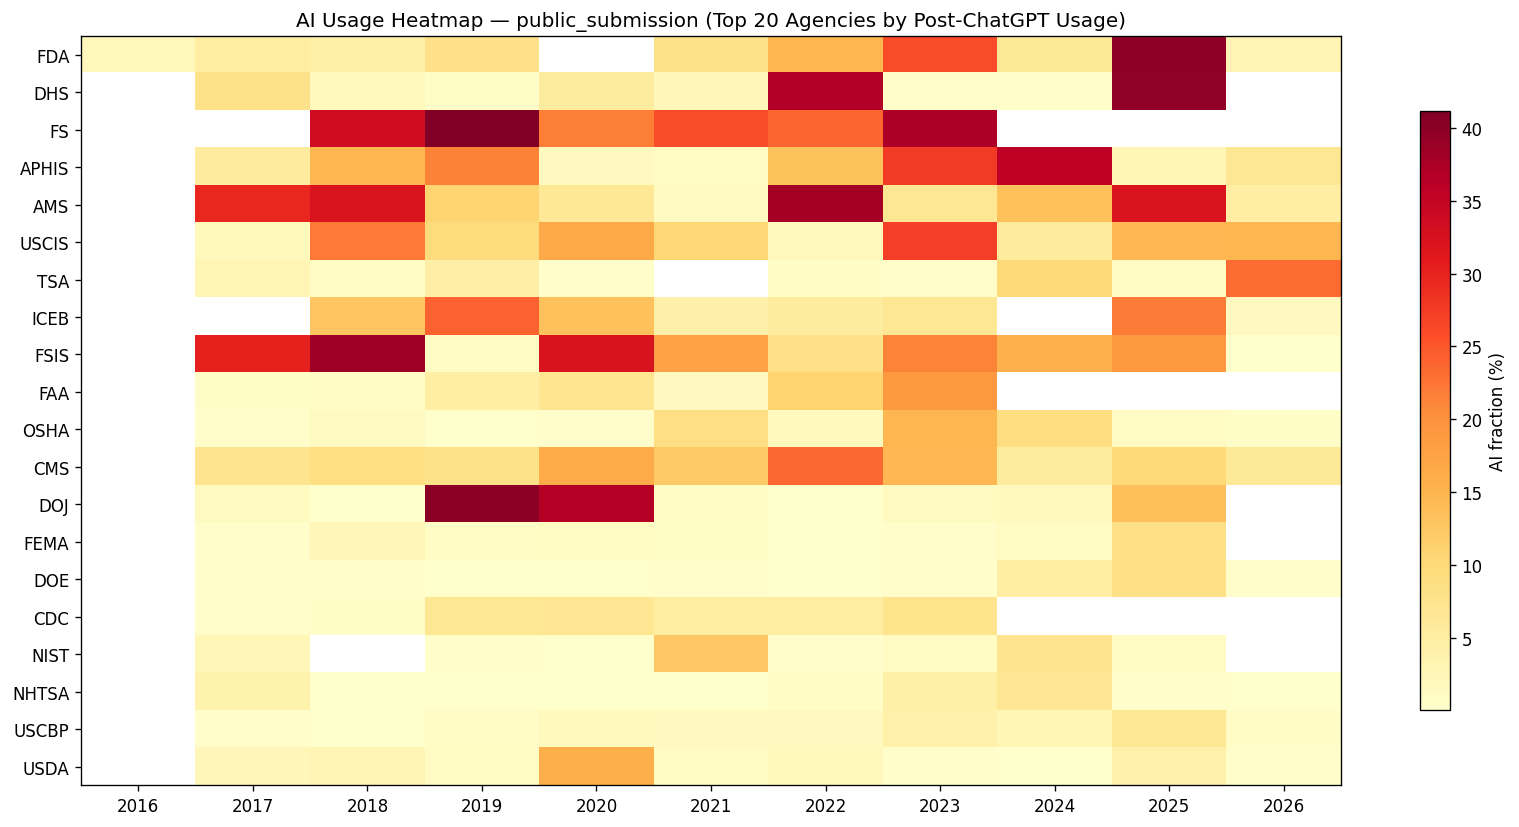

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_42859/1671630497.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['alpha_estimate'], weights=g['n_sentences']))


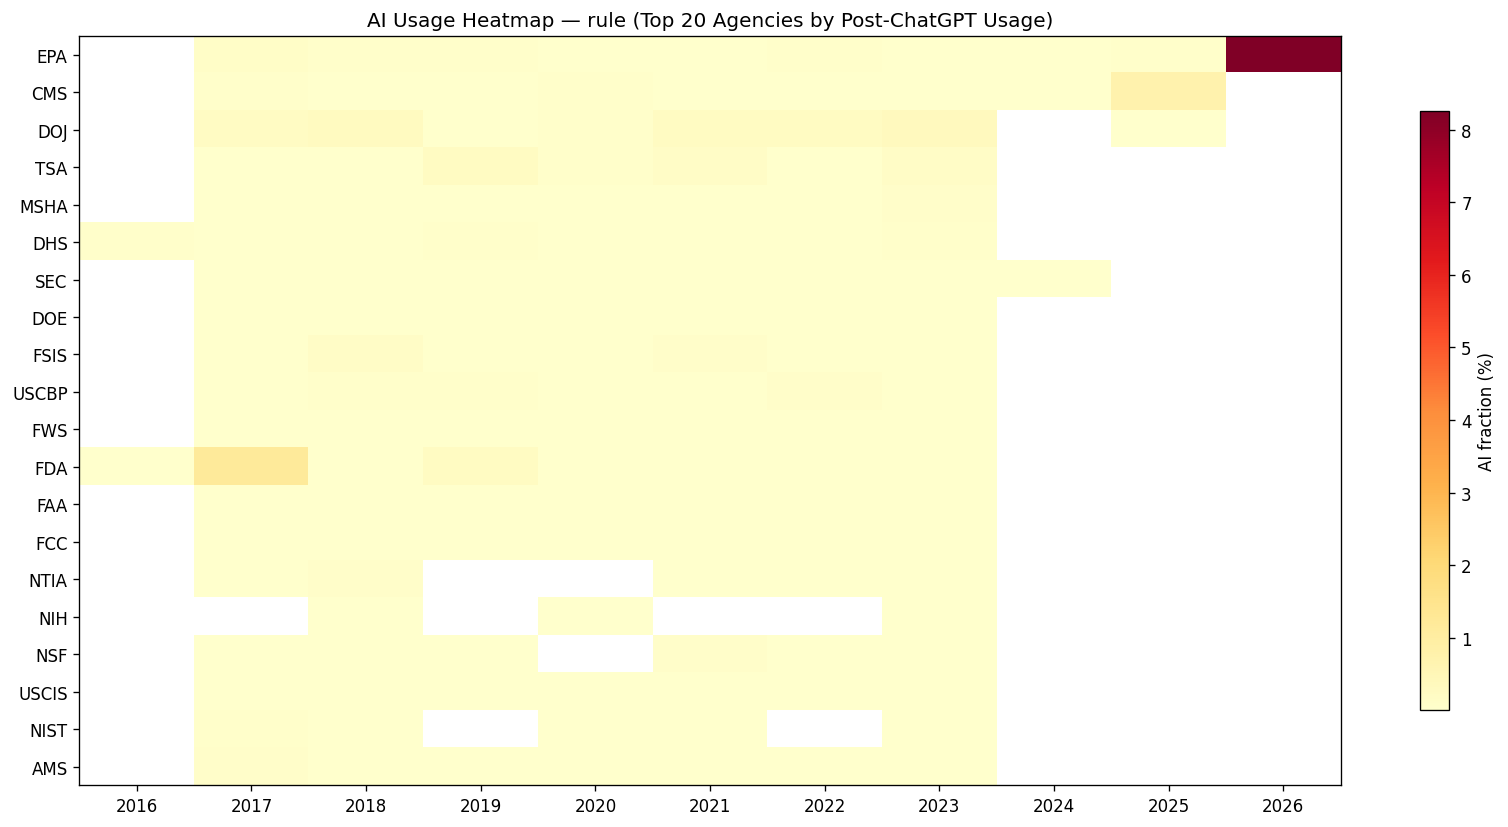

In [47]:
for doc_type in df['doc_type'].unique():
    subset = df[df['doc_type'] == doc_type]
    yearly = (
        subset.groupby(['agency_id', 'year'])
        .apply(lambda g: np.average(g['alpha_estimate'], weights=g['n_sentences']))
        .reset_index(name='alpha_weighted')
    )
    
    pivot = yearly.pivot(index='agency_id', columns='year', values='alpha_weighted')
    
    # Filter to agencies that have post-ChatGPT data and sort by max alpha
    post_cols = [c for c in pivot.columns if c >= 2023]
    if post_cols:
        pivot = pivot[pivot[post_cols].notna().any(axis=1)]
        pivot = pivot.loc[pivot[post_cols].max(axis=1).sort_values(ascending=False).index]
        pivot = pivot.head(20)  # top 20 agencies
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.35)))
    im = ax.imshow(pivot.values * 100, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(int))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    plt.colorbar(im, ax=ax, label='AI fraction (%)', shrink=0.8)
    ax.set_title(f'AI Usage Heatmap — {doc_type} (Top 20 Agencies by Post-ChatGPT Usage)')
    plt.tight_layout()
    plt.show()